In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import particle
from particle import Particle
import seaborn as sns
from funcs import Neutrinos_dk2nu

DET_I = 5 #SBND Index
DET_A = 4*np.pi*1e4 # Detector area

data = Neutrinos_dk2nu("./DATA/NuBeam_production_BooNE_50m_I174000A_0.dk2nu.root")


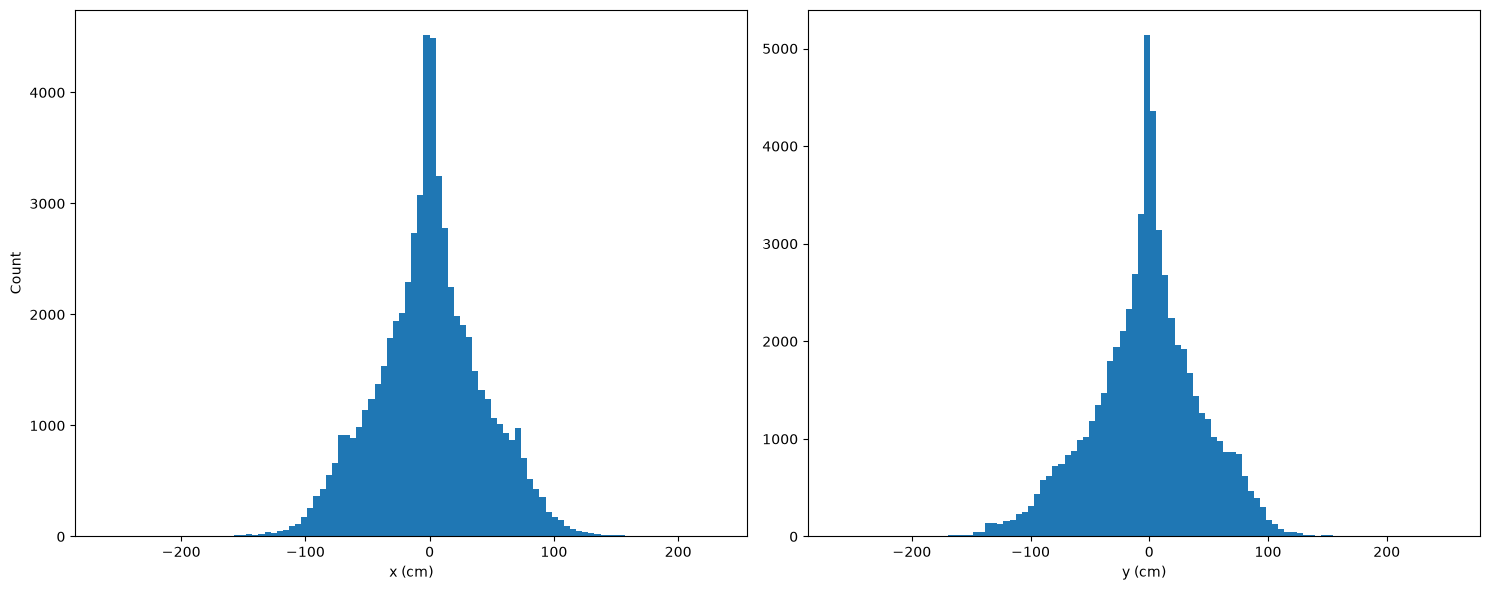

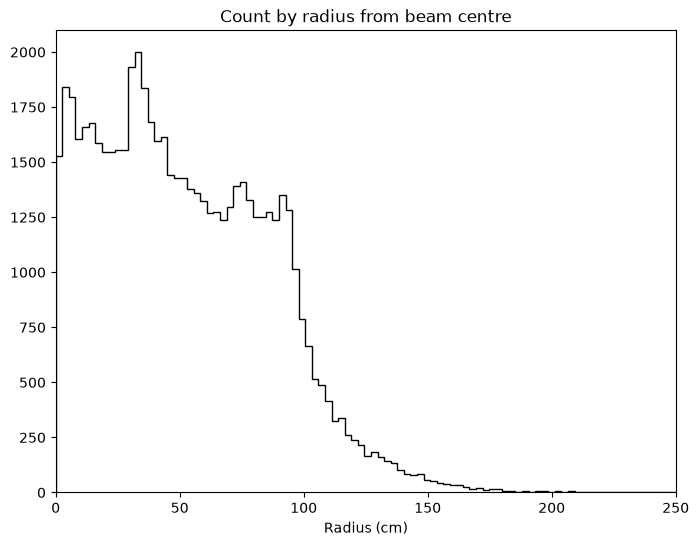

In [2]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
ax1.hist(data.decay_x, bins=100)
ax2.hist(data.decay_y, bins=100)

ax1.set_xlabel("x (cm)")
ax1.set_ylabel("Count")
ax2.set_xlabel("y (cm)")

fig.tight_layout()

radii = np.sqrt(data.decay_x**2 + data.decay_y**2)
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(radii, bins=100,histtype="step", color="black")

ax.set_xlim(0,250)
ax.set_xlabel("Radius (cm)")
ax.set_title("Count by radius from beam centre")
plt.show()

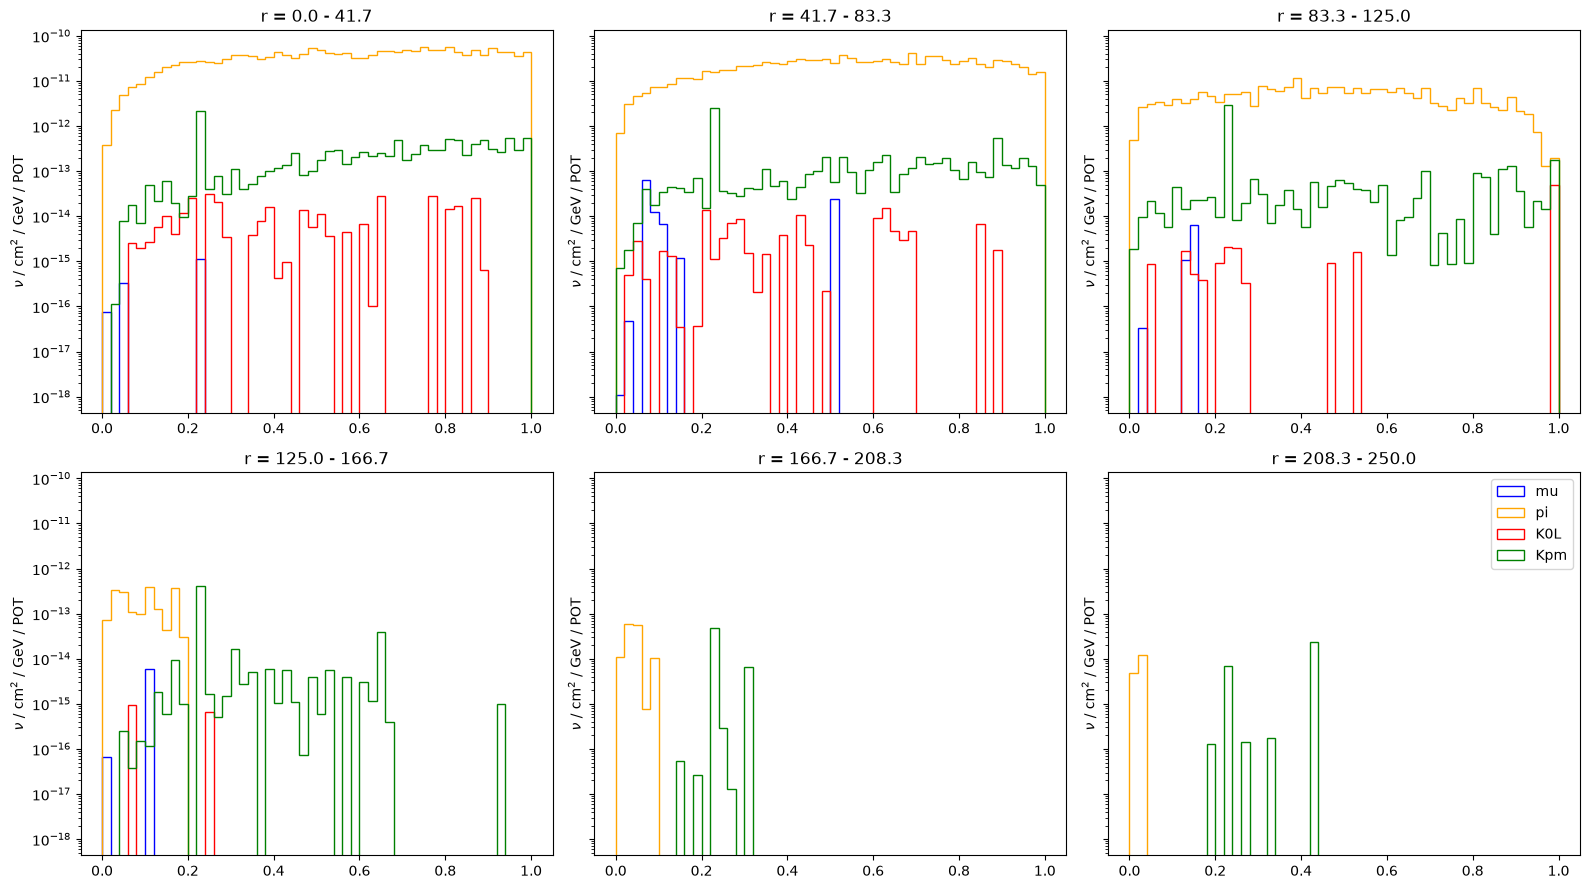

KDAR energy window: 235-236 MeV (0.235-0.236 GeV)
0.0-41.7 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.483, Events=43.43640339570183
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.517, Events=46.40737872350584

41.7-83.3 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.171, Events=10.98756200385883
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.829, Events=53.231095188907936

83.3-125.0 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.099, Events=6.787361519508942
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.901, Events=62.05632181239678

125.0-166.7 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=1.000, Events=8.91984763369061

166.7-208.3 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=1.000, Events=1.0409971868713725

208.3-250.0 cm
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : rati

In [3]:


rows, columns = 2, 3
fig, axs = plt.subplots(rows,columns, figsize=(16, 9), sharey=True)
bins = np.linspace(0, 1, 51)  # GeV

nbins = rows * columns
edges = np.linspace(0,250,nbins+1)

radial_masks = []
for i in range(len(edges)-1):
    radial_masks.append((radii >= edges[i]) & (radii < edges[i+1]))



for r in range(rows):
    for c in range(columns):
        
        mask = data.flavour_mask(14) & radial_masks[r*columns + c] & data.energy_mask()

        for label, (parent_pdgs, colour) in data.parent_groups.items():
                full_mask = mask & data.parent_mask(parent_pdgs)
                axs[r][c].hist(data.energies[full_mask], bins=bins, weights=data.tot_wgts[full_mask],
                        label=label, color=colour, histtype="step", linewidth=1)

        axs[r][c].set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
        axs[r][c].set_yscale("log")
        axs[r][c].set_title(f"r = {(r*columns + c)*(250/nbins):.1f} - {(r*columns + c+1)*(250/nbins):.1f}")

axs[rows-1][columns-1].legend()
fig.tight_layout()
plt.show()


kdar_mask = data.energy_mask([0.235,0.236])
print("KDAR energy window: 235-236 MeV (0.235-0.236 GeV)")

for i in range(len(edges)-1):
    edge_lo = edges[i]
    edge_hi = edges[i+1]
    rmask = radial_masks[i]
    mask =  rmask & kdar_mask & data.flavour_mask(14)

    total_weighted = np.sum(data.tot_wgts[mask])
    total_counts = np.count_nonzero(mask)

    print(f"{edge_lo:.1f}-{edge_hi:.1f} cm")
    if total_weighted <= 0:
        print("  (no events in this bin)")
        continue

    for label, (p_pdgs, colour) in data.parent_groups.items():
        w = np.sum(data.tot_wgts[mask & data.parent_mask(p_pdgs)])
        n = np.count_nonzero(mask & data.parent_mask(p_pdgs))
        event_count = data.event_count([0.235,0.236], 14, p_pdgs, rmask)
        ratio = w / total_weighted
        print(f"  {label:4s}: ratio={ratio:.3f}, Events={event_count}")

    print()

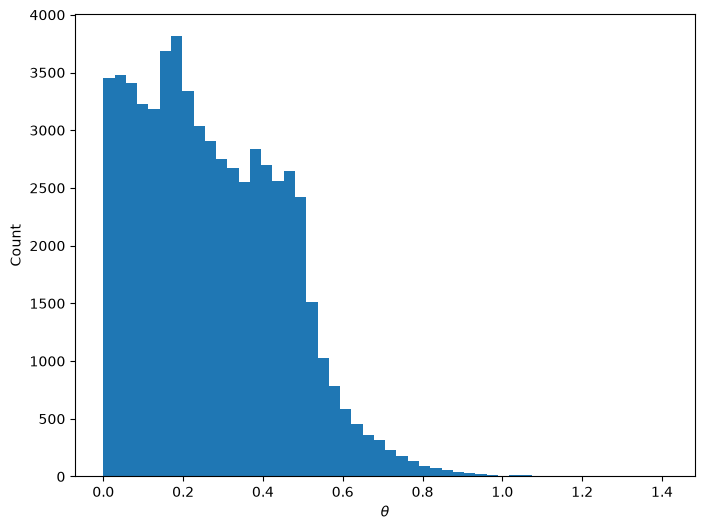

In [4]:
fig, ax = plt.subplots(figsize=(8,6))

thetas = np.degrees(np.arctan2(radii, data.decay_x + 1.1e4))

#ax.fill_between([0.4, 1.5], 0, 4000, color="red", alpha=0.2)
ax.hist(thetas, bins=50)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Count")


plt.show()

KDAR energy window: 235-236 MeV (0.235-0.236 GeV)
0.00-0.17 (theta)
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.513, Events=31.581536804762596
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.487, Events=29.87785347974074
0.17-0.33 (theta)
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.337, Events=19.34839224379452
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.663, Events=38.074840276988006
0.33-0.50 (theta)
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.142, Events=10.281620830379856
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=0.858, Events=62.557411266172394
0.50-0.67 (theta)
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=1.000, Events=32.35096388733257
0.67-0.83 (theta)
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, Events=0.0
  Kpm : ratio=1.000, Events=7.280484792348016
0.83-1.00 (theta)
  mu  : ratio=0.000, Events=0.0
  pi  : ratio=0.000, Events=0.0
  K0L : ratio=0.000, E

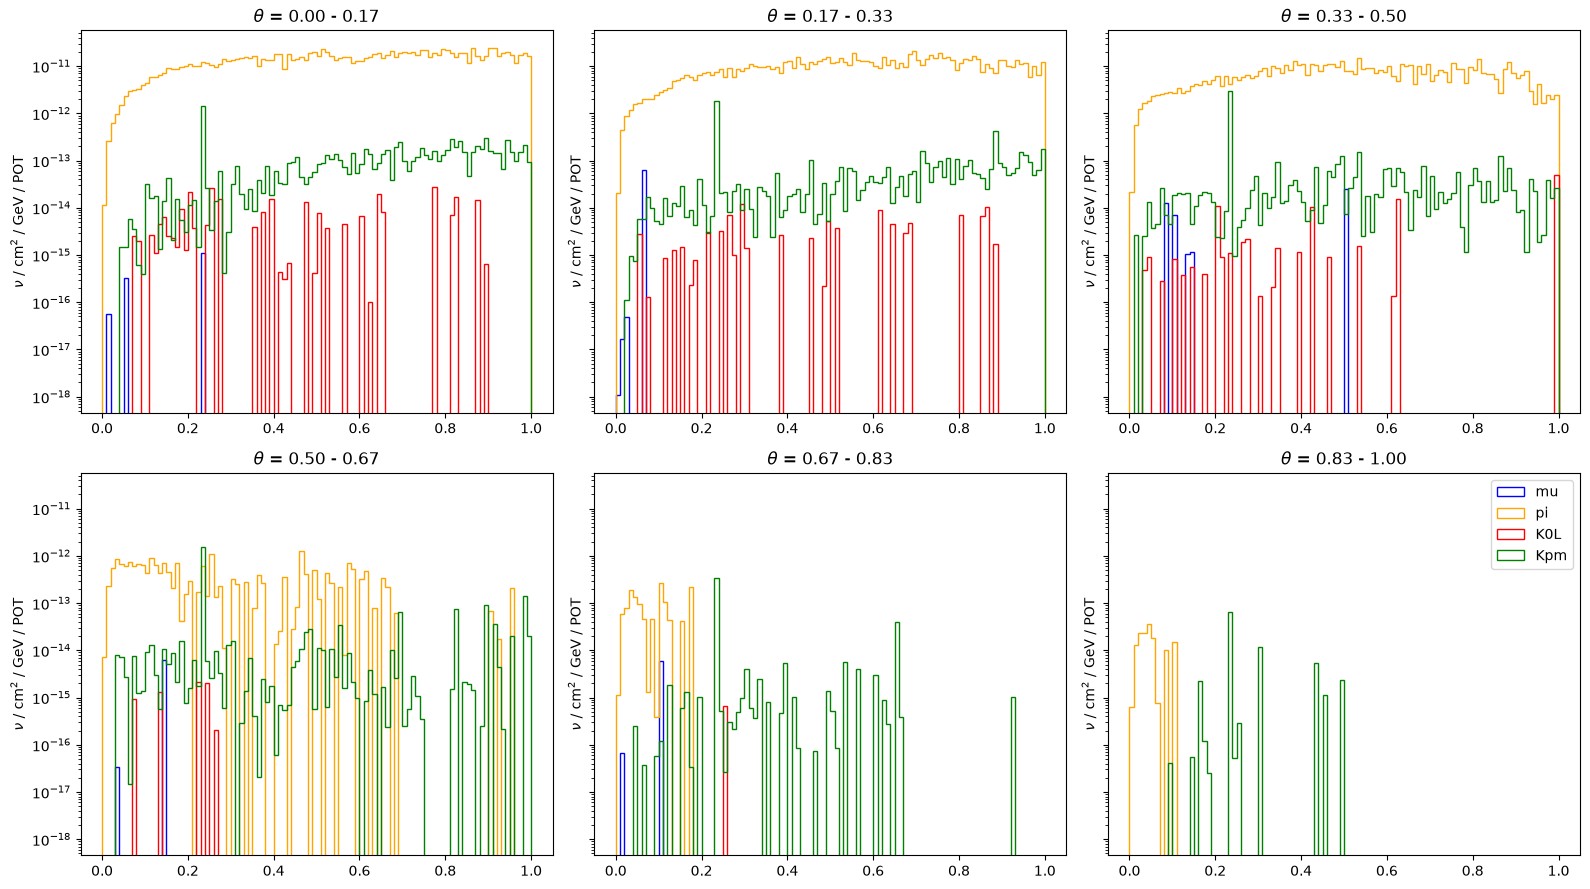

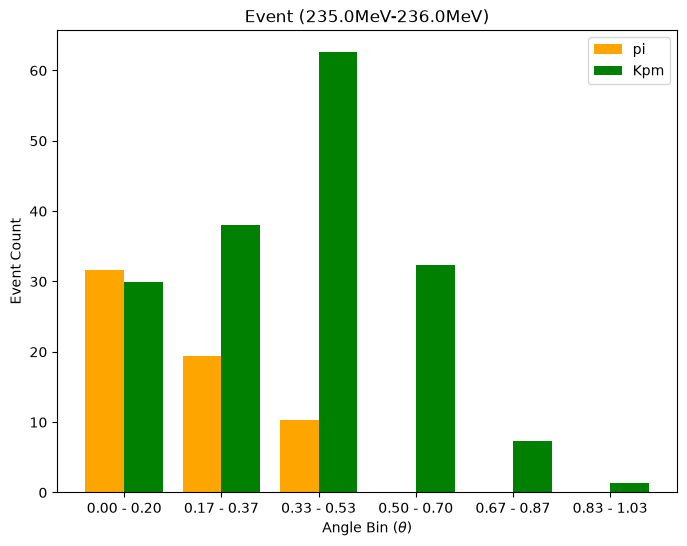

In [5]:

def kdar_angle_bins(data, thetas, e_range):

    rows, columns = 2, 3
    fig, axs = plt.subplots(rows,columns, figsize=(16, 9), sharey=True)
    bins = np.linspace(0, 1, 101)  # GeV
    nbins = rows * columns
    edges = np.linspace(0,1,nbins+1)

    angle_masks = []
    for i in range(len(edges)-1):
        angle_masks.append((thetas >= edges[i]) & (thetas < edges[i+1]))



    for r in range(rows):
        for c in range(columns):
            
            mask = data.flavour_mask(14) & angle_masks[r*columns + c] & data.energy_mask()

            for label, (parent_pdgs, colour) in data.parent_groups.items():
                    full_mask = mask & data.parent_mask(parent_pdgs)
                    axs[r][c].hist(data.energies[full_mask], bins=bins, weights=data.tot_wgts[full_mask],
                            label=label, color=colour, histtype="step", linewidth=1)

            axs[r][c].set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
            axs[r][c].set_yscale("log")
            axs[r][c].set_title(r"$\theta$" + f" = {(r*columns + c)*(1/nbins):.2f} - {(r*columns + c+1)*(1/nbins):.2f}")

    axs[rows-1][columns-1].legend()
    fig.tight_layout()


    kdar_mask = data.energy_mask(e_range)
    print("KDAR energy window: 235-236 MeV (0.235-0.236 GeV)")


    labels       = [f"{i:.2f} - {i+0.2:.2f}" for i in edges[:-1]]
    event_counts = {
        "mu" : [],
        "pi"  : [],
        "K0L" : [], 
        "Kpm": []
    }

    for i in range(len(edges)-1):

        edge_lo = edges[i]
        edge_hi = edges[i+1]
        angle_mask = angle_masks[i]
        mask =  angle_mask & kdar_mask & data.flavour_mask(14)

        total_weighted = np.sum(data.tot_wgts[mask])
        total_counts = np.count_nonzero(mask)

        print(f"{edge_lo:.2f}-{edge_hi:.2f} (theta)")
        if total_weighted <= 0:
            print("  (no events in this bin)")
            continue

        for label, (p_pdgs, colour) in data.parent_groups.items():
            w = np.sum(data.tot_wgts[mask & data.parent_mask(p_pdgs)])
            n = np.count_nonzero(mask & data.parent_mask(p_pdgs))
            event_count = data.event_count(e_range, 14, p_pdgs, angle_mask)
            event_counts[label].append(event_count)
            ratio = w / total_weighted
            print(f"  {label:4s}: ratio={ratio:.3f}, Events={event_count}")

        
    fig, ax = plt.subplots(figsize=(8,6))
    x = np.arange(6)
    x = x/2
    ax.bar(x-0.1, event_counts["pi"], width=0.2, color=data.parent_groups["pi"][1])
    ax.bar(x+0.1, event_counts["Kpm"], width=0.2, color=data.parent_groups["Kpm"][1])
    ax.set_xticks(x, labels)
    ax.legend(["pi", "Kpm"])
    ax.set_ylabel("Event Count")
    ax.set_xlabel(r"Angle Bin ($\theta$)")
    ax.set_title(f"Event ({e_range[0]*1000}MeV-{e_range[1]*1000}MeV)")

    plt.show()

kdar_angle_bins(data, thetas, [0.235,0.236])

# Wider Bin
#kdar_angle_bins(data, thetas, [0.230,0.240])


Optimal Cut: >= 0.35478 degrees.
KDAR Score: 7.24632


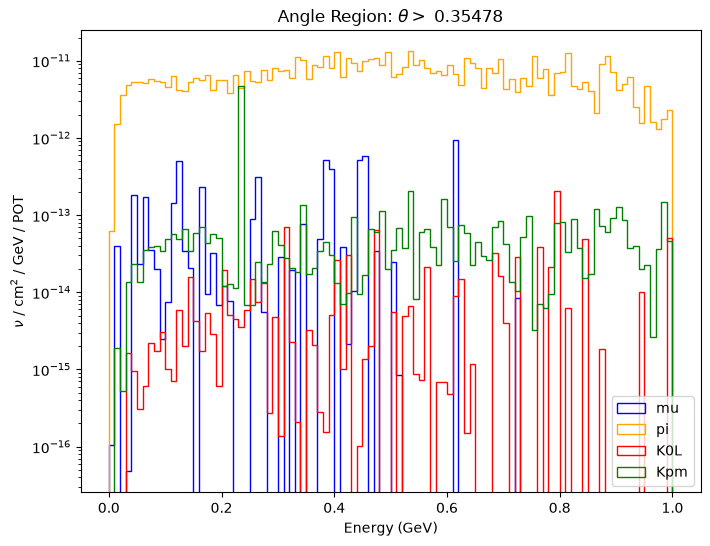

In [32]:
# Optimise Angle Cut Position

from scipy import optimize


e_range           = [0.230,0.240]

def calculate_kdar_metric(data, angle):

    angle_mask = thetas >= angle    

    kdar_count = data.event_count(e_range, 14, [321, -321, 230], angle_mask)
    pion_count = data.event_count(e_range, 14, [211, -211], angle_mask)
    score = kdar_count / np.sqrt(kdar_count + pion_count)
    return score

res = scipy.optimize.minimize_scalar(lambda x: -1 * calculate_kdar_metric(data, x), method="bounded", bounds=[0, 1.5])
print(f"Optimal Cut: >= {res.x:.5f} degrees.")
print(f"KDAR Score: {-1 * res.fun:.5f}")

fig, ax = plt.subplots(figsize=(8, 6))
bins = np.linspace(0,1, 101) # 10 MeV buckets to align with opimisation

for label, (parent_pdgs, colour) in data.parent_groups.items():
    full_mask = data.energy_mask() & data.parent_mask(parent_pdgs) & (thetas >= res.x)
    ax.hist(data.energies[full_mask], bins=bins, weights=data.tot_wgts[full_mask],
                    label=label, color=colour, histtype="step", linewidth=1)

ax.set_title(r"Angle Region: $\theta >$ " + f"{res.x:.5f}")
ax.set_yscale('log')
ax.set_ylabel(r"$\nu$ / cm$^2$ / GeV / POT")
ax.set_xlabel('Energy (GeV)')    
ax.legend()
